# Studio qualità — Embedding, Dedup, Clustering

Analisi **as-is** di quanto prodotto da `pathos embed` (embedding + dedup + clustering) sul DB reale.
Nessun fix, nessuna feature: obiettivo è mappare copertura e criticità con esempi concreti,
tutto eseguito qui dentro (nessuna query fuori dal notebook).

Riferimento codice: `pathosphere/semantic/embedder.py`, `dedup.py`, `cluster.py`.

In [1]:
import sys, struct, random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "pathosphere").exists():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

from pathosphere.db.schema import get_connection

DB_PATH = REPO_ROOT / "data" / "db" / "pathosphere.db"
conn = get_connection(DB_PATH)
print(f"DB: {DB_PATH}  exists={DB_PATH.exists()}")

def q(sql, params=()):
    return pd.read_sql_query(sql, conn, params=params)

q("SELECT COUNT(*) AS raw_documents FROM raw_documents")


DB: /Users/dom/Documents/GitHub/pathosphere/data/db/pathosphere.db  exists=True


,raw_documents
0,176477


## 1. Copertura embedding

Quanti `raw_documents` sono stati effettivamente embeddati, deduplicati, marcati NER.

In [2]:
cov = q("""
SELECT
  COUNT(*) AS total,
  SUM(embedded) AS embedded,
  SUM(is_duplicate) AS duplicates,
  SUM(dedup_checked) AS dedup_checked,
  SUM(ner_done) AS ner_done
FROM raw_documents
""")
cov

,total,embedded,duplicates,dedup_checked,ner_done
0,176477,176477,46605,176477,129872


In [3]:
by_origin = q("""
SELECT origin, COUNT(*) AS n, SUM(embedded) AS embedded, SUM(is_duplicate) AS dup
FROM raw_documents GROUP BY origin ORDER BY n DESC
""")
by_origin

,origin,n,embedded,dup
0,gdelt,174286,174286,46196
1,rss,1939,1939,247
2,comtrade,252,252,162


## 2. Clustering vs backfill storico

`cluster_documents` (`semantic/cluster.py:71-82`) filtra i candidati su
`COALESCE(published_at, fetched_at) >= now - 72h`, calcolato al momento in cui il comando
gira — non una finestra relativa ai dati. Ipotesi da verificare: il backfill storico GDELT
(gennaio→oggi, ingerito con `gdelt-history`) potrebbe essere rimasto in gran parte fuori
da questa finestra se `pathos embed`/`cluster` sono girati una sola volta a fine backfill.
Ma se `embed` è stato rilanciato più volte durante il backfill (finestre 72h diverse ogni
volta), la copertura cumulativa può essere molto più alta della finestra singola — lo
verifichiamo sui numeri reali sotto, senza assumere l'esito.

In [4]:
total_docs = int(q("SELECT COUNT(*) AS n FROM raw_documents")["n"][0])
docs_in_events = int(q("SELECT COUNT(DISTINCT document_id) AS n FROM event_documents")["n"][0])
pct = docs_in_events / total_docs * 100 if total_docs else 0
print(f"raw_documents totali: {total_docs}")
print(f"documenti assegnati a un evento (clusterizzati): {docs_in_events} ({pct:.1f}%)")
print(f"documenti MAI passati da cluster_documents: {total_docs - docs_in_events} ({100 - pct:.1f}%)")

raw_documents totali: 176477
documenti assegnati a un evento (clusterizzati): 175818 (99.6%)
documenti MAI passati da cluster_documents: 659 (0.4%)


In [5]:
oldest_clustered = q("""
SELECT MIN(COALESCE(r.published_at, r.fetched_at)) AS oldest,
       MAX(COALESCE(r.published_at, r.fetched_at)) AS newest
FROM raw_documents r JOIN event_documents ed ON ed.document_id = r.id
""")
oldest_clustered

,oldest,newest
0,2026-01-01T00:00:00,2026-07-06T00:00:00+00:00


## 3. Distribuzione dimensione cluster (eventi da articoli)

In [6]:
sizes = q("""
SELECT e.id, e.origin, COUNT(ed.document_id) AS n_docs
FROM events e JOIN event_documents ed ON ed.event_id = e.id
GROUP BY e.id
""")
sizes["n_docs"].describe()

count    116012.000000
mean          1.898536
std           3.470295
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max         155.000000
Name: n_docs, dtype: float64

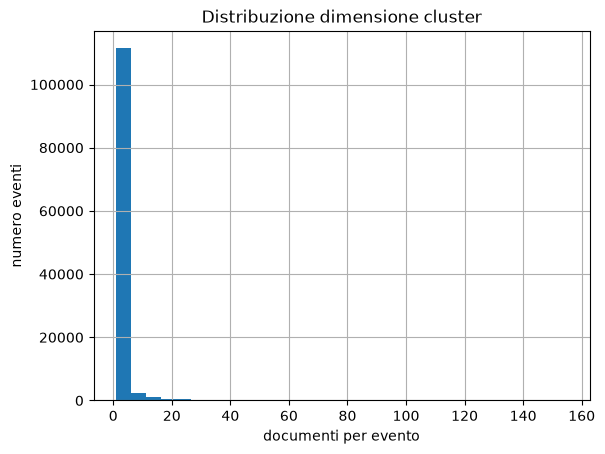

Eventi al cap max_cluster_size=30: 378
Eventi singleton (1 doc): 89838 su 116012 (77.4%)


In [7]:
sizes["n_docs"].hist(bins=30)
plt.xlabel("documenti per evento"); plt.ylabel("numero eventi")
plt.title("Distribuzione dimensione cluster")
plt.show()

print(f"Eventi al cap max_cluster_size=30: {(sizes['n_docs'] >= 30).sum()}")
print(f"Eventi singleton (1 doc): {(sizes['n_docs'] == 1).sum()} su {len(sizes)} "
      f"({(sizes['n_docs'] == 1).mean() * 100:.1f}%)")

## 4. Coerenza titoli — cluster più grandi (esempi concreti)

In [8]:
big_clusters = sizes.sort_values("n_docs", ascending=False).head(5)["id"].tolist()
for eid in big_clusters:
    titles = q(
        "SELECT r.title FROM event_documents ed JOIN raw_documents r ON r.id = ed.document_id "
        "WHERE ed.event_id = ?",
        params=(int(eid),),
    )
    print(f"\n=== Evento {eid} ({len(titles)} doc) ===")
    for t in titles["title"].head(12):
        print(" -", t)


=== Evento 1191 (155 doc) ===
 - GDELT: CREDIT UNION →  [110]
 - GDELT: INDUSTRY →  [111]
 - GDELT: MAYOR →  [114]
 - GDELT: NAVY →  [111]
 - GDELT: BANK →  [114]
 - GDELT: JUDGE →  [110]
 - GDELT: ATTORNEY →  [110]
 - GDELT: PROSECUTOR →  [112]
 - GDELT: COURT OF APPEALS →  [110]
 - GDELT: GOVERNMENT →  [110]
 - GDELT: GOVERNMENT → RELIGION [111]
 - GDELT: ADMINISTRATION →  [111]

=== Evento 1219 (104 doc) ===
 - GDELT: ATTORNEY →  [112]
 - GDELT:  → SECURITY OFFICER [172]
 - GDELT: POLICE →  [173]
 - GDELT: AUTHORITIES →  [120]
 - GDELT: SCHOOL →  [172]
 - GDELT: SCHOOL →  [1721]
 - GDELT: SECRETARY OF STATE → VOTER [173]
 - GDELT: ADMINISTRATION →  [111]
 - GDELT: AUTHORITIES →  [173]
 - GDELT: PROSECUTOR →  [173]
 - GDELT:  → GOVERNMENT [173]
 - GDELT: PRISON →  [173]

=== Evento 113957 (97 doc) ===
 - GDELT:  → SUPREME COURT [111]
 - GDELT: CRIMINAL →  [114]
 - GDELT: GOVERNMENT → UNITED STATES [112]
 - GDELT: SUPREME COURT →  [120]
 - GDELT: GARRISON →  [112]
 - GDELT:  → DETECT

## 5. Qualità dedup — coppie concrete + similarità coseno reale

In [9]:
dup_pairs = q("""
SELECT r.id AS dup_id, r.title AS dup_title, r.duplicate_of AS canon_id, c.title AS canon_title
FROM raw_documents r JOIN raw_documents c ON c.id = r.duplicate_of
WHERE r.is_duplicate = 1
LIMIT 15
""")

def get_embedding(doc_id):
    row = conn.execute("SELECT embedding FROM vec_documents WHERE document_id = ?", (doc_id,)).fetchone()
    if row is None:
        return None
    return np.array(struct.unpack("384f", row["embedding"]), dtype=np.float32)

def cosine(a, b):
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))

for _, row in dup_pairs.iterrows():
    va, vb = get_embedding(int(row.dup_id)), get_embedding(int(row.canon_id))
    sim = cosine(va, vb) if va is not None and vb is not None else None
    print(f"\ndup   {row.dup_id}: {row.dup_title}")
    print(f"canon {row.canon_id}: {row.canon_title}")
    print(f"cosine similarity: {sim:.4f}" if sim is not None else "embedding mancante")


dup   5769: I Royal Marines fermano una petroliera della flotta-ombra russa
canon 5756: Spettacolare blitz nella Manica contro una nave russa
cosine similarity: 0.9644

dup   5793: Putin, Trump discuss bilateral relations, international situation — Kremlin aide
canon 5775: Putin’s congratulations to Trump were informal — Kremlin aide
cosine similarity: 0.9334

dup   5794: Putin talks to Trump over phone, congratulates him on his 80th birthday
canon 5784: Putin notes mutual understanding he has developed with Trump
cosine similarity: 0.9231

dup   5801: Israel notifies US before striking Beirut — media
canon 5781: Trump says infuriated over Netanyahu’s decision to strike Beirut — media
cosine similarity: 0.9208

dup   5851: World Cup 2026: Germany overpower tournament debutant Curaçao
canon 5773: Germany defeats Curacao 7-1 in 2026 FIFA World Cup group stage match
cosine similarity: 0.9200

dup   5855: Swiss police fire tear gas as anti-G7 protesters target UN buildings
canon 5829: Pro

## 6. Eventi da sensori fisici mescolati ai cluster articoli

`events` accoglie direttamente righe da USGS/FIRMS/PortWatch/IODA (`origin` diverso da
gdelt/rss) senza passare da `cluster_documents`. Verifichiamo quanti sono e se mai finiscono
raggruppati con articoli.

In [10]:
origin_counts = q("SELECT origin, COUNT(*) AS n FROM events GROUP BY origin ORDER BY n DESC")
origin_counts

,origin,n
0,gdelt,115376
1,portwatch,4904
2,usgs,1062
3,rss,636
4,ioda,219
5,firms,60


In [11]:
physical_origins = {"usgs", "firms", "portwatch", "ioda"}
phys = origin_counts[origin_counts["origin"].isin(physical_origins)]
print(f"Eventi da sensori fisici: {phys['n'].sum()} su {origin_counts['n'].sum()} totali")

phys_sizes = sizes[sizes["origin"].isin(physical_origins)]
print(f"di cui con >1 documento associato (mai capitato per costruzione): "
      f"{(phys_sizes['n_docs'] > 1).sum()} su {len(phys_sizes)}")

Eventi da sensori fisici: 6245 su 122257 totali
di cui con >1 documento associato (mai capitato per costruzione): 0 su 0


## Sintesi criticità osservate in questo run

In [12]:
print("--- Sintesi (valori da questo run) ---")
print(f"1. Copertura clustering: {pct:.1f}% dei raw_documents è mai entrato in un evento "
      f"({total_docs - docs_in_events} doc esclusi per costruzione dalla finestra 72h).")
print(f"2. Eventi singleton: {(sizes['n_docs'] == 1).mean() * 100:.1f}% dei cluster ha un solo documento.")
print(f"3. Eventi al cap max_cluster_size=30: {(sizes['n_docs'] >= 30).sum()} — "
      "verificare sopra se i titoli restano coerenti o già mescolati a ridosso del cap.")
print(f"4. Eventi da sensori fisici: {phys['n'].sum()} — mai clusterizzati con articoli (per design, non per fix).")

--- Sintesi (valori da questo run) ---
1. Copertura clustering: 99.6% dei raw_documents è mai entrato in un evento (659 doc esclusi per costruzione dalla finestra 72h).
2. Eventi singleton: 77.4% dei cluster ha un solo documento.
3. Eventi al cap max_cluster_size=30: 378 — verificare sopra se i titoli restano coerenti o già mescolati a ridosso del cap.
4. Eventi da sensori fisici: 6245 — mai clusterizzati con articoli (per design, non per fix).
